#SMS Spam Classification


**A simple text classification model that detects whether an SMS message
is "spam" or "ham" (not spam).**

**Author: Maryam Yaqoob (FA23-BAI-025)**

In [37]:
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


**1. Load Dataset**

In [38]:
# Dataset: SMS Spam Collection (Kaggle Version)

df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only the required columns
df = df[["v1", "v2"]]

# Rename columns
df.columns = ["label", "text"]

print(f"Dataset shape: {df.shape}")
print(df["label"].value_counts())

Dataset shape: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


*Plotting Class Distribution*

label
ham     4825
spam     747
Name: count, dtype: int64


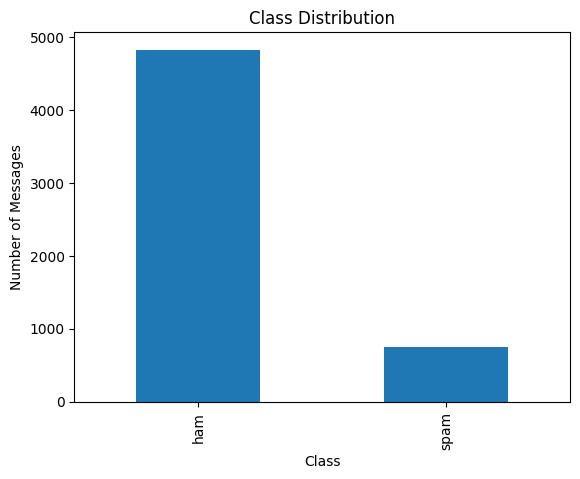

In [39]:
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()

**2. Preprocessing**

In [40]:
# Dataset: SMS Spam Collection (Kaggle Version)

df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only the required columns
df = df[["v1", "v2"]]

# Rename columns
df.columns = ["label", "text"]

print(f"Dataset shape: {df.shape}")
print(df["label"].value_counts())



def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"\d+", "", text)                     # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()            # remove extra whitespace
    return text

df["clean_text"] = df["text"].apply(clean_text)
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

Dataset shape: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


**3. Train/Test Split**

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_num"]
)

**4. Feature Extraction (TF-IDF)**

In [42]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

**5. Train Model (Logistic Regression)**

In [43]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

**6. Evaluate Model**

In [44]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== Model Performance =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))



===== Model Performance =====
Accuracy : 0.9632
Precision: 0.9909
Recall   : 0.7315
F1-Score : 0.8417

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



*Plotting Confusion Matrix*

Confusion Matrix:

[[965   1]
 [ 40 109]]


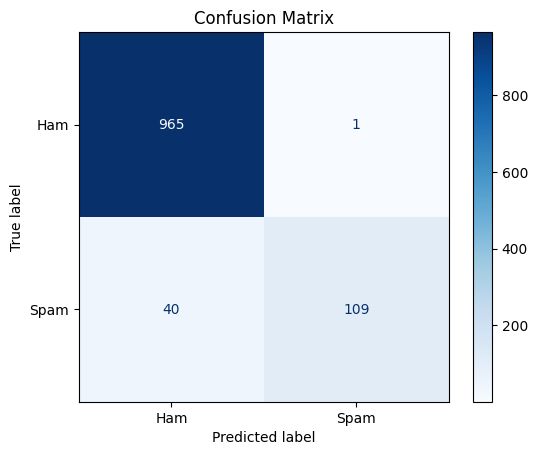

In [45]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

*Plotting Evaluation Matrix*

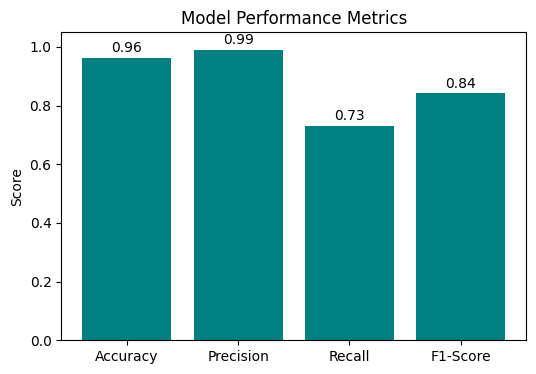

In [46]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(6, 4))
plt.bar(metrics, scores, color = "teal")
plt.ylim(0, 1.05)
plt.title("Model Performance Metrics")
plt.ylabel("Score")

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()

**7. Try the model on a few custom examples**

In [47]:
samples = [
    "Congratulations! You won a free iPhone, click here to claim now!!!",
    "Hey, are we still meeting for lunch tomorrow?",
]

samples_clean = [clean_text(s) for s in samples]
samples_tfidf = vectorizer.transform(samples_clean)
preds = model.predict(samples_tfidf)

for s, p in zip(samples, preds):
    print(f"\nMessage: {s}")
    print(f"Prediction: {'SPAM' if p == 1 else 'HAM'}")


Message: Congratulations! You won a free iPhone, click here to claim now!!!
Prediction: SPAM

Message: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM
